# Project Repository

## 📦 GitHub Repository

You can find all the deliverables for this project in the following GitHub repository:

[🔗 View Project Repository](https://github.com/Mohamedelzayat123/DEEP-LEARNING-TASKS/tree/MNIST-CLASSIFICATION)

---

Feel free to check the repository for the Jupyter Notebook, README file, and other relevant files related to the Iris Classification project.


# **Import Required Libraries**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.metrics import SparseCategoricalAccuracy,CategoricalAccuracy
from tensorflow.keras.losses import SparseCategoricalCrossentropy,CategoricalCrossentropy
from tensorflow.keras.datasets import mnist
from PIL import Image
import math

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Load MNIST Data**

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# **Visualize Sample**

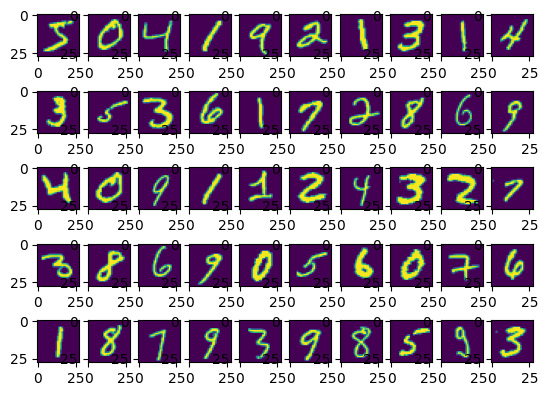

In [3]:
fig, axs = plt.subplots(5, 10)
cnt = 0
for i in range(5):
     for j in range(10):
         axs[i, j].imshow(X_train[cnt])
         cnt += 1

In [4]:
print('The shape of the training inputs:', X_train.shape)
print('The shape of the training labels:',y_train.shape)
print('The shape of the testing inputs:',X_test.shape)
print('The shape of the testing labels:',y_test.shape)

The shape of the training inputs: (60000, 28, 28)
The shape of the training labels: (60000,)
The shape of the testing inputs: (10000, 28, 28)
The shape of the testing labels: (10000,)


# **Apply Normalization**

In [5]:
# Normalize the images.
X_train = (X_train / 255) - 0.5
X_test = (X_test / 255) - 0.5

# **Data Augmentation**

In [6]:
# Reshape the data to add a channel dimension (for compatibility with ImageDataGenerator)
X_train = np.expand_dims(X_train, axis=-1)

# Create a mask for selecting 3/4 of the data
mask = np.random.choice([False, True], size=len(X_train), p=[1/20, 19/20])

# Create an ImageDataGenerator instance with the desired augmentation options
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.005,
    zoom_range=0.05,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)

# Fit the ImageDataGenerator on the selected subset of training data
datagen.fit(X_train[mask])

# Generate augmented images in batches and add them to the original data
augmented_images = datagen.flow(X_train[mask], y_train[mask], batch_size=len(X_train[mask]), shuffle=False)

# Extract augmented images and labels from the generator
x_augmented, y_augmented = augmented_images.__next__()

# Concatenate original and augmented data
x_train_augmented = np.concatenate((X_train, x_augmented))
y_train_augmented = np.concatenate((y_train, y_augmented))
print("Shape of augmented training set:", x_train_augmented.shape, y_train_augmented.shape)

Shape of augmented training set: (116953, 28, 28, 1) (116953,)


In [7]:
# Function to shift an image by one pixel in a given direction
def shift_image(image, direction):
    shifted_image = np.roll(image, shift=direction, axis=(0, 1))
    return shifted_image

# Create shifted copies of each image in the training set
directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]  # Left, right, up, down
x_train_shifted = []
y_train_shifted = []
for image, label in zip(X_train, y_train):
    for direction in directions:
        shifted_image = shift_image(image, direction)
        x_train_shifted.append(shifted_image)
        y_train_shifted.append(label)

# Convert the lists to numpy arrays
x_train_shifted = np.array(x_train_shifted)
y_train_shifted = np.array(y_train_shifted)

# Add the shifted copies to the original training set
x_train_augmented = np.concatenate((x_train_augmented, x_train_shifted))
y_train_augmented = np.concatenate((y_train_augmented, y_train_shifted))
# Add the shifted copies to the original training set
x_train_augmented = np.concatenate((x_train_augmented, X_train))
y_train_augmented = np.concatenate((y_train_augmented, y_train))

# Shuffle the augmented training set
shuffle_indices = np.random.permutation(len(x_train_augmented))
X_train = x_train_augmented[shuffle_indices]
y_train = y_train_augmented[shuffle_indices]

# Display the shape of the augmented training set
print("Shape of augmented training set:", X_train.shape, y_train.shape)

Shape of augmented training set: (416953, 28, 28, 1) (416953,)


In [8]:
X_train = x_train_augmented
y_train = y_train_augmented
# Reshape the images.
X_train = np.expand_dims(X_train, axis=3)
X_test = np.expand_dims(X_test, axis=3)

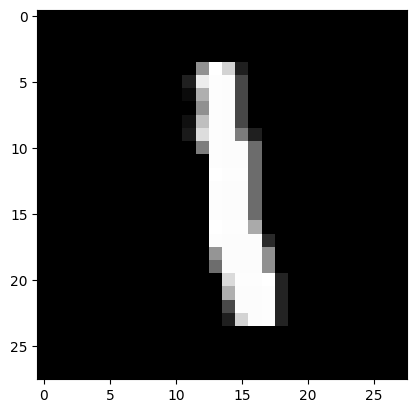

In [9]:
plt.imshow(X_train[6][:,:,0],cmap='gray')#,cmap='grayscale' google greyscale in matplot
plt.show()

In [10]:
y_train[6]

1

# **Bulid the Model**

In [11]:
n_epochs = 100
initializer = RandomNormal(mean=0., stddev=1.)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization
from tensorflow.keras.initializers import GlorotUniform  # Example initializer

# Use a specific initializer if needed (replace 'initializer' with this or any other)
initializer = GlorotUniform()

model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # This flattens the input to 1D
    Dense(512, activation='relu', kernel_initializer=initializer),
    BatchNormalization(),
    Dense(256, activation='relu', kernel_initializer=initializer),
    BatchNormalization(),
    Dense(128, activation='relu', kernel_initializer=initializer),
    BatchNormalization(),
    Dense(64, activation='relu', kernel_initializer=initializer),
    BatchNormalization(),
    Dense(10, activation='softmax', kernel_initializer=initializer)  # Output layer for 10 classes
])

model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 578,890 (2.21 MB)

 Trainable params: 576,970 (2.20 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [13]:
# Ensure X_train and X_test have the correct shape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Corrected shape of X_train:", X_train.shape)  # (num_samples, 28, 28, 1)
print("Corrected shape of X_test:", X_test.shape)    # (num_samples, 28, 28, 1)



Corrected shape of X_train: (416953, 28, 28, 1)
Corrected shape of X_test: (10000, 28, 28, 1)


# **Train The Model**

In [14]:
X_train = np.expand_dims(X_train, axis=-1)  # Ensure correct input shape
X_test = np.expand_dims(X_test, axis=-1)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss=CategoricalCrossentropy(),
    metrics=[CategoricalAccuracy()],
)

history = model.fit(
    X_train,
    to_categorical(y_train),
    epochs=n_epochs,
    validation_data=(X_test, to_categorical(y_test)),
    callbacks=[early_stopping]
)


Epoch 1/100
13030/13030 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - categorical_accuracy: 0.9264 - loss: 0.2374 - val_categorical_accuracy: 0.9822 - val_loss: 0.0564
Epoch 2/100
13030/13030 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - categorical_accuracy: 0.9716 - loss: 0.0890 - val_categorical_accuracy: 0.9845 - val_loss: 0.0479
Epoch 3/100
13030/13030 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - categorical_accuracy: 0.9793 - loss: 0.0643 - val_categorical_accuracy: 0.9829 - val_loss: 0.0536
Epoch 4/100
13030/13030 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - categorical_accuracy: 0.9828 - loss: 0.0534 - val_categorical_accuracy: 0.9853 - val_loss: 0.0456
Epoch 5/100
13030/13030 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - categorical_accuracy: 0.9850 - loss: 0.0465 - val_categorical_accuracy: 0.9858 - val_loss: 0.0465
Epoch 6/100
13030/13030 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - categorical_accuracy: 0.9867 - loss: 0.0412 - val_categorical_accuracy: 0.9876 - val_loss: 0.0389
Epoch 7/100
13030/13030 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms

# **Visulaize The Loss and Accuracy Over Epochs**

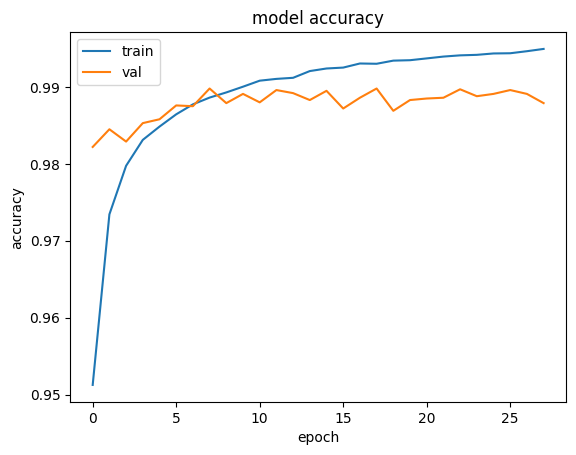

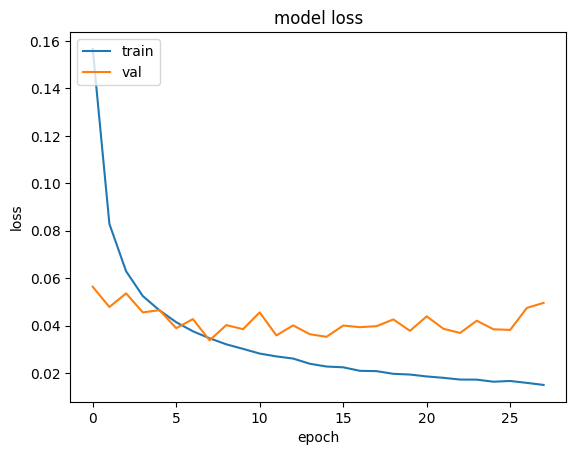

In [15]:
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# **GOT 99.01% ACCURACY!!! ✌**

In [16]:
_, accuracy = model.evaluate(X_test, to_categorical(y_test))
print('Accuracy: %.2f' % (accuracy * 100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.9864 - loss: 0.0477
Accuracy: 98.98


# **Predict Sample**

In [17]:
predictions = model.predict(X_test[:5])
print(predictions.shape)
print(predictions)


# Print our model's predictions.
print("Predictions")
print(np.argmax(predictions, axis=1)) # [7, 2, 1, 0, 4]

print("Data")
# Check our predictions
print(y_test[:5]) # [7, 2, 1, 0, 4]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
(5, 10)
[[1.87732326e-06 1.96437412e-07 1.35208086e-06 5.98299494e-07
  4.15620285e-08 1.61559569e-07 3.12570342e-06 9.99992013e-01
  3.91728854e-08 5.61885770e-07]
 [6.28863003e-11 1.01385673e-07 9.99999881e-01 2.88477315e-11
  3.26659218e-13 4.76155336e-14 2.81947451e-11 2.93021857e-11
  1.29995070e-09 9.23148190e-12]
 [2.33968311e-08 9.99996305e-01 4.46253061e-08 1.40092844e-08
  7.48168638e-09 4.03834797e-08 2.19394792e-06 3.03631076e-08
  1.10038286e-06 4.83616361e-07]
 [9.99946475e-01 1.06149393e-07 5.52347365e-06 8.04590854e-06
  1.62046765e-09 1.01778278e-06 6.01042757e-06 1.36686875e-08
  1.71821705e-06 3.11983895e-05]
 [8.73932038e-09 8.93147046e-07 4.57711849e-07 3.25280416e-06
  9.99788165e-01 3.11614983e-08 4.91050343e-07 8.85651559e-07
  1.02150705e-06 2.04780008e-04]]
Predictions
[7 2 1 0 4]
Data
[7 2 1 0 4]


In [18]:
# Function to display images with their predicted labels
def display_images(images, labels_true, labels_pred, rows=5):
    cols = math.ceil(len(images) / rows)
    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"True: {labels_true[i]}, Pred: {labels_pred[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step


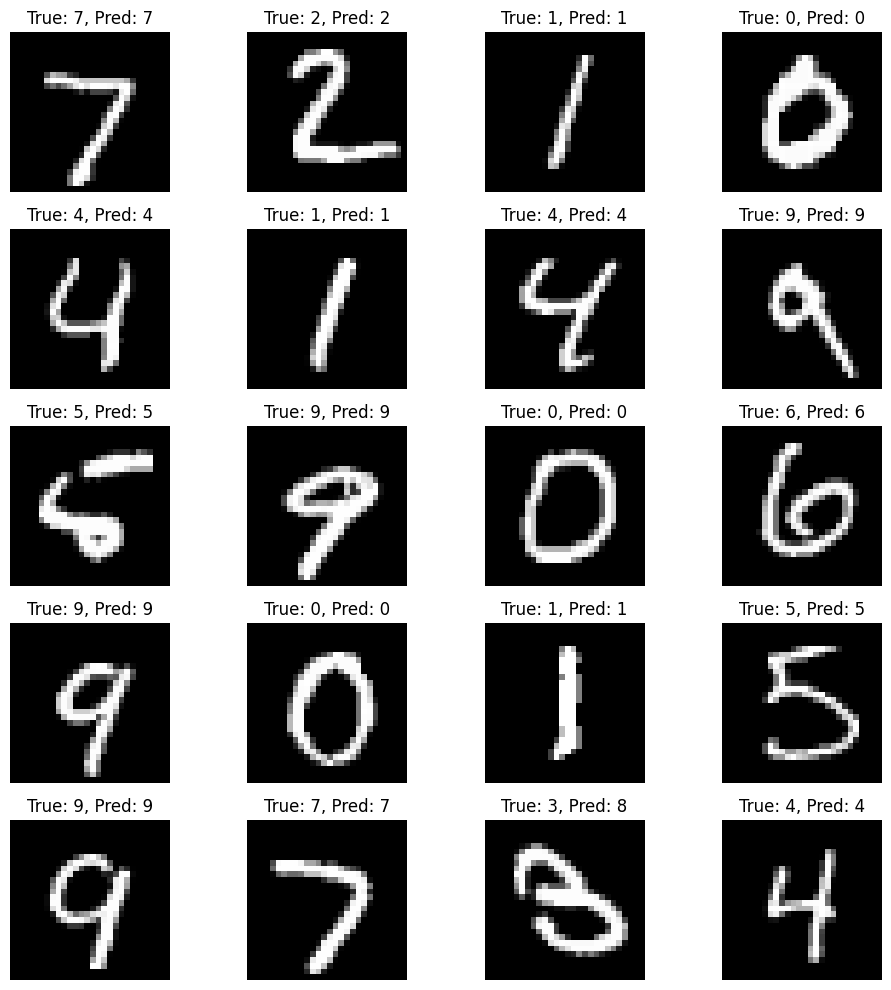

In [19]:
# Make predictions on the first 20 test images
predictions = model.predict(X_test[:20])

# Display the images along with their predicted labels in 5 rows
display_images(X_test[:20, :, :, 0], y_test[:20], np.argmax(predictions, axis=1), rows=5)